#Know Your ZIP - Miami-Dade County


##Data Upload

In [3]:
import pandas as pd
import io
import requests

ModuleNotFoundError: No module named 'pandas'

In [ ]:
income_zip = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/IncomeByZip.csv")
pop_per_zip = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/PopulationByZip.csv")
fire_station = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/Fire_Station.csv")
police_station = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/PoliceStation_gdb_-1134624143014171098.csv")
private_school = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/Private_School.csv")
public_school = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/SchoolSite_gdb_-5745748764799769002.csv")
park_facility = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/Park_Facility.csv")
hotel_zip = pd.read_csv("https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/HotelMotelInn_gdb_-4704617087620911628.csv")

In [ ]:
# Fetch the data for Hospitals
url = "https://raw.githubusercontent.com/BetsySnchzB/DatasetsP/refs/heads/main/Hospitalpoly_gdb_2921453914923425143.csv"
response = requests.get(url)
response.raise_for_status()  # Raise HTTPError for bad responses (4xx or 5xx)

# Read the CSV data with error handling
try:
    hospital_zip = pd.read_csv(io.StringIO(response.text))
except pd.errors.ParserError as e:
    print(f"ParserError: {e}")
    # Attempt to fix the error by handling extra delimiters
    hospital_zip = pd.read_csv(
        io.StringIO(response.text),
        sep=",",  # Specify the delimiter (comma)
        quotechar='"',  # Specify the quote character (double quote)
        escapechar='\\',  # Specify the escape character (backslash)
        on_bad_lines='warn',  # Print warnings for bad lines instead of skipping
    )
    # Display potential problem lines for further inspection
    print("Potential problem lines:")
    print(hospital_zip[hospital_zip.isnull().any(axis=1)])

ParserError: Error tokenizing data. C error: Expected 9 fields in line 6, saw 10

Potential problem lines:
    OBJECTID                                             NAME  Created_By  \
0          1                     Nicklaus Children's Hospital         NaN   
1          2                    West Kendall Baptist Hospital         NaN   
2          3                  South Miami Hospital East Tower         NaN   
3          4                            Coral Gables Hospital         NaN   
4          6                                 Hialeah Hospital         NaN   
5          7                               Homestead Hospital         NaN   
6          8               Jackson Behavioral Health Hospital         NaN   
7         10                       Miami VA Healthcare System         NaN   
8         11                  Promise Hospital of Miami Lakes         NaN   
9         12     HealthSouth Rehabilitation Hospital of Miami         NaN   
10        13                      Helping Hand

<ipython-input-3-abf812407b93>:12: ParserWarning: Skipping line 6: expected 9 fields, saw 10
Skipping line 10: expected 9 fields, saw 10

  hospital_zip = pd.read_csv(


# Population per Zip

In [ ]:
pop_per_zip.head()
pop_per_zip.columns
pop_per_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Rank      129 non-null    int64 
 1   ZIP Code  129 non-null    object
 2   Value     129 non-null    object
dtypes: int64(1), object(2)
memory usage: 3.2+ KB


In [ ]:
# Clean ZIP code

pop_per_zip['ZIP'] = pop_per_zip['ZIP Code'].str.split(',').str[0].str.strip().str.zfill(5)

In [ ]:
# Clean Population values and convert to numeric

pop_per_zip['Population'] = pop_per_zip['Value'].str.replace(',', '').astype(int)

In [ ]:
#Drop unnecessary columns

pop_per_zip_clean = pop_per_zip[['ZIP', 'Population']]

In [ ]:
pop_per_zip_clean.head()

,ZIP,Population
0,33157,69605
1,33012,69408
2,33033,69075
3,33015,68430
4,33186,67597


# Income Zip

In [ ]:
income_zip.head()
income_zip.columns
income_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76 entries, 0 to 75
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Rank      76 non-null     int64 
 1   ZIP Code  76 non-null     object
 2   Value     76 non-null     object
dtypes: int64(1), object(2)
memory usage: 1.9+ KB


In [ ]:
income_zip.head()

,Rank,ZIP Code,Value
0,1,"33158, FL","189,886"
1,2,"33149, FL","181,429"
2,3,"33156, FL","160,859"
3,4,"33131, FL","157,198"
4,5,"33031, FL","141,397"


In [ ]:
#Convert zip cpdes to 5 digits strings

income_zip['ZIP'] = income_zip['ZIP Code'].astype(str).str.extract(r'(\d{5})')

In [ ]:
#convert value to numeric

income_zip['INCOME'] = income_zip['Value'].str.replace(',', '').astype(int)

In [ ]:
#Drop and reorder columns

income_zip_clean = income_zip[['ZIP', 'INCOME']]

In [ ]:
income_zip_clean.head()

,ZIP,INCOME
0,33158,189886
1,33149,181429
2,33156,160859
3,33131,157198
4,33031,141397


# Fire Station

In [ ]:
fire_station.head()
fire_station.columns
fire_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X         73 non-null     float64
 1   Y         73 non-null     float64
 2   OBJECTID  73 non-null     int64  
 3   FOLIO     73 non-null     object 
 4   ID        73 non-null     int64  
 5   NAME      73 non-null     object 
 6   ADDRESS   73 non-null     object 
 7   CITY      73 non-null     object 
 8   ZIPCODE   73 non-null     int64  
 9   MUNICID   73 non-null     int64  
 10  TYPE      73 non-null     object 
 11  LAT       73 non-null     float64
 12  LON       73 non-null     float64
 13  POINT_X   73 non-null     float64
 14  POINT_Y   73 non-null     float64
 15  GlobalID  73 non-null     object 
dtypes: float64(6), int64(4), object(6)
memory usage: 9.3+ KB


In [ ]:
fire_station.head()

,X,Y,OBJECTID,FOLIO,ID,NAME,ADDRESS,CITY,ZIPCODE,MUNICID,TYPE,LAT,LON,POINT_X,POINT_Y,GlobalID
0,-8.946451e+06,2.946033e+06,1,3660070000552,34,Cutler Bay Fire 34,10850 SW 211TH ST,Cutler Bay,33189,30,B,25.57091,-80.36734,864717.362114,450235.771429,{A878BAEF-0A5E-4466-AA76-32AC09A8C5CA}
1,-8.937234e+06,2.976976e+06,2,0530240061390,35,Miami Springs Fire 35,201 WESTWARD DR,Miami Springs,33166,5,B,25.82138,-80.28455,891519.248347,541412.021626,{CA6C96D2-F049-45D4-83BE-82B5430EE6BC}
2,-8.952774e+06,2.965449e+06,3,3049220220920,37,West Bird Fire St 37,4200 SW 142ND AVE,Miami-Dade,33175,30,B,25.72814,-80.42414,845745.125040,507295.562586,{2636A092-18C9-4053-97D6-F1D924297429}
3,-8.929248e+06,2.993791e+06,4,3411360000094,38,Norland Fire 38,575 NW 199TH ST,Miami Gardens,33169,30,B,25.95727,-80.21279,914823.165169,590939.433640,{B3264F37-085A-4F10-A3FA-7919F2C40D82}
4,-8.938445e+06,2.969627e+06,5,1540120000170,40,West Miami Fire St 40,975 SW 62ND AVE,West Miami,33144,15,B,25.76194,-80.29556,888055.438296,519788.575846,{9820FF39-62D1-430F-86F2-2ED4FDE82C4B}


In [ ]:
# Keep relevant columns

columns_to_keep_fire = ['ZIPCODE', 'NAME', 'ADDRESS', 'LAT', 'LON']
fire_station_clean = fire_station[columns_to_keep_fire].copy()

In [ ]:
#Standardize ZIP format

fire_station_clean['ZIP'] = fire_station_clean['ZIPCODE'].astype(str).str.zfill(5)
fire_station_clean.drop(columns=['ZIPCODE'], inplace=True)

In [ ]:
fire_station_clean.head()

,NAME,ADDRESS,LAT,LON,ZIP
0,Cutler Bay Fire 34,10850 SW 211TH ST,25.57091,-80.36734,33189
1,Miami Springs Fire 35,201 WESTWARD DR,25.82138,-80.28455,33166
2,West Bird Fire St 37,4200 SW 142ND AVE,25.72814,-80.42414,33175
3,Norland Fire 38,575 NW 199TH ST,25.95727,-80.21279,33169
4,West Miami Fire St 40,975 SW 62ND AVE,25.76194,-80.29556,33144


Count Fire Stations per ZIP

In [ ]:
#Aggregate fire station count per ZIP

fire_station_counts = fire_station_clean.groupby('ZIP').size().reset_index(name='FIRE_STATION_COUNT')

In [ ]:
fire_station_counts.head()

,ZIP,FIRE_STATION_COUNT
0,33014,1
1,33015,1
2,33016,2
3,33030,1
4,33031,1


# Police Station

In [ ]:
police_station.head()
police_station.columns
police_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   OBJECTID  8 non-null      int64  
 1   FOLIO     8 non-null      int64  
 2   NAME      8 non-null      object 
 3   ADDRESS   8 non-null      object 
 4   CITY      8 non-null      object 
 5   ZIPCODE   8 non-null      int64  
 6   LAT       8 non-null      float64
 7   LON       8 non-null      float64
 8   POINT_X   8 non-null      float64
 9   POINT_Y   8 non-null      float64
 10  x         8 non-null      float64
 11  y         8 non-null      float64
dtypes: float64(6), int64(3), object(3)
memory usage: 900.0+ bytes


In [ ]:
police_station.head()

,OBJECTID,FOLIO,NAME,ADDRESS,CITY,ZIPCODE,LAT,LON,POINT_X,POINT_Y,x,y
0,1,3220240180030,Northwest Station,5975 Miami Lakes Dr,Miami Lakes,33014,25.91011,-80.29838,886796.624562,573635.624969,-8.938774e+06,2.987952e+06
1,2,3530280110010,Midwest Station,9101 NW 25th St,Doral,33172,25.79764,-80.34339,872202.124552,532679.891592,-8.943785e+06,2.974039e+06
2,3,3040310000170,Kendall Station,7707 SW 117th Ave,Miami-Dade,33183,25.69613,-80.38112,859964.243844,495727.644302,-8.947984e+06,2.961495e+06
3,4,3059030122860,Hammocks Station,10000 SW 142nd Ave,Miami-Dade,33186,25.67464,-80.42293,846228.100056,487852.581723,-8.952639e+06,2.958839e+06
4,5,622160000020,Intracoastal Station,15665 Biscayne Blvd,North Miami,33160,25.92010,-80.15498,933910.431663,577547.744770,-8.922811e+06,2.989190e+06


In [ ]:
#standarize zip codes

police_station['ZIP'] = police_station['ZIPCODE'].astype(str).str.zfill(5)

In [ ]:
#Keep relevant columns

columns_to_keep_police = ['ZIP', 'NAME', 'ADDRESS', 'LAT', 'LON']
police_stations_clean = police_station[columns_to_keep_police].copy()

In [ ]:
#Missing values

police_stations_clean.dropna(subset=['ZIP', 'LAT', 'LON'], inplace=True)

In [ ]:
police_stations_clean.head()

,ZIP,NAME,ADDRESS,LAT,LON
0,33014,Northwest Station,5975 Miami Lakes Dr,25.91011,-80.29838
1,33172,Midwest Station,9101 NW 25th St,25.79764,-80.34339
2,33183,Kendall Station,7707 SW 117th Ave,25.69613,-80.38112
3,33186,Hammocks Station,10000 SW 142nd Ave,25.67464,-80.42293
4,33160,Intracoastal Station,15665 Biscayne Blvd,25.92010,-80.15498


Count of Stations per ZIP

In [ ]:
#Aggregate

police_station_counts = police_stations_clean.groupby('ZIP').size().reset_index(name='POLICE_STATION_COUNT')

In [ ]:
police_station_counts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   ZIP                   8 non-null      object
 1   POLICE_STATION_COUNT  8 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 260.0+ bytes


# Private School

In [ ]:
private_school.head()
private_school.columns
private_school.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 34 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   X             975 non-null    float64
 1   Y             975 non-null    float64
 2   OBJECTID      975 non-null    int64  
 3   FOLIO         975 non-null    int64  
 4   NAME          975 non-null    object 
 5   ADDRESS       975 non-null    object 
 6   UNIT          779 non-null    object 
 7   CITY          972 non-null    object 
 8   ZIPCODE       975 non-null    int64  
 9   PHONE         974 non-null    object 
 10  EMAIL         0 non-null      float64
 11  DIRCTNAME     967 non-null    object 
 12  YEARESTB      740 non-null    object 
 13  TYPE          729 non-null    object 
 14  GRDLEVEL      975 non-null    object 
 15  COED          963 non-null    object 
 16  STREGFLG      728 non-null    object 
 17  CHLDCAREID    970 non-null    object 
 18  ENROLLMENT    753 non-null    

In [ ]:
private_school.head()

,X,Y,OBJECTID,FOLIO,NAME,ADDRESS,UNIT,CITY,ZIPCODE,PHONE,...,POINT_Y,CREATEDBY,CREATEDDATE,MODIFIEDBY,MODIFIEDDATE,GlobalID,CreationDate,Creator,EditDate,Editor
0,-8.926098e+06,2.978238e+06,1,132180340010,The Cushman School,592 NE 60th St,,Miami,33137,305-757-1966,...,545313.096317,ABREUI,2018/04/30 16:37:05+00,ABREUI,2018/04/30 16:37:05+00,c46d57ca-2f17-4ffc-a8c7-339362249c4a,2025/01/28 16:27:14.070+00,MDPublisher,2025/01/28 16:27:14.070+00,MDPublisher
1,-8.946243e+06,2.977707e+06,2,3530170010391,Divine Savior Lutheran Academy,10311 NW 58th St,,Doral,33178,305-597-4545,...,543424.249724,E316899,2020/11/04 18:20:05+00,E316899,2020/11/04 18:20:05+00,b19a90ee-1c60-4ad5-a0ac-5106c8e42f90,2025/01/28 16:27:14.070+00,MDPublisher,2025/01/28 16:27:14.070+00,MDPublisher
2,-8.941108e+06,2.969585e+06,3,3040110220010,Apple Learning Center,860 SW 76th Ct,,Miami-Dade,33144,305-261-4133,...,519624.374886,ABREUI,2018/04/13 16:20:00+00,E316899,2021/07/29 09:32:48+00,b1e0544a-6c85-4246-9f4a-3c537b33246c,2025/01/28 16:27:14.070+00,MDPublisher,2025/01/28 16:27:14.070+00,MDPublisher
3,-8.946716e+06,2.962322e+06,4,3040300650030,Kayleen's Learning Center,10855 SW 72nd St,30,Miami-Dade,33173,305-274-5553,...,498178.943314,E316899,2020/11/04 18:20:05+00,E316899,2020/11/04 18:20:05+00,e0143f7a-49b8-4abb-8264-07343023dc7f,2025/01/28 16:27:14.070+00,MDPublisher,2025/01/28 16:27:14.070+00,MDPublisher
4,-8.937092e+06,2.957997e+06,5,2051070000060,True North Early Learning Acadmey,11295 SW 57th Ave,NaN,Pinecrest,33156,786-628-7801,...,485599.551889,E316899,2020/12/07 10:43:52+00,E316899,2020/12/07 10:51:49+00,57bfa075-f0cd-4ce4-813c-b16b061e385f,2025/01/28 16:27:14.070+00,MDPublisher,2025/01/28 16:27:14.070+00,MDPublisher


In [ ]:
#Keep relevant columns

columns_to_keep_private = ['ZIPCODE', 'NAME', 'ADDRESS', 'LAT', 'LON']
private_school_clean = private_school[columns_to_keep_private].copy()

In [ ]:
#Standardize zips

private_school_clean['ZIP'] = private_school_clean['ZIPCODE'].astype(str).str.zfill(5)
private_school_clean.drop(columns=['ZIPCODE'], inplace=True)

In [ ]:
#Drop missing zip codes

private_school_clean.dropna(subset=['ZIP', 'LAT', 'LON'], inplace=True)

In [ ]:
private_school_clean.head()

,NAME,ADDRESS,LAT,LON,ZIP
0,The Cushman School,592 NE 60th St,25.83159,-80.18450,33137
1,Divine Savior Lutheran Academy,10311 NW 58th St,25.82730,-80.36547,33178
2,Apple Learning Center,860 SW 76th Ct,25.76161,-80.31934,33144
3,Kayleen's Learning Center,10855 SW 72nd St,25.70283,-80.36972,33173
4,True North Early Learning Acadmey,11295 SW 57th Ave,25.66782,-80.28326,33156


Aggregate per ZIP

In [ ]:
private_school_counts = private_school_clean.groupby('ZIP').size().reset_index(name='PRIVATE_SCHOOL_COUNT')

In [ ]:
private_school_counts.head()

,ZIP,PRIVATE_SCHOOL_COUNT
0,33010,29
1,33012,41
2,33013,18
3,33014,31
4,33015,18


# Public School

In [ ]:
public_school.head()
public_school.columns
public_school.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 27 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OBJECTID       445 non-null    int64  
 1   FOLIO          445 non-null    int64  
 2   ID             445 non-null    int64  
 3   NAME           445 non-null    object 
 4   CAMPUS         445 non-null    object 
 5   ADDRESS        445 non-null    object 
 6   UNIT           445 non-null    object 
 7   CITY           445 non-null    object 
 8   ZIPCODE        445 non-null    int64  
 9   PHONE          445 non-null    object 
 10  EMAIL          0 non-null      float64
 11  TYPE           445 non-null    object 
 12  GRADES         445 non-null    object 
 13  CAPACITY       445 non-null    int64  
 14  ENROLLMNT      445 non-null    int64  
 15  REGION         445 non-null    object 
 16  LAT            445 non-null    float64
 17  LON            445 non-null    float64
 18  POINT_X   

In [ ]:
public_school.head()

,OBJECTID,FOLIO,ID,NAME,CAMPUS,ADDRESS,UNIT,CITY,ZIPCODE,PHONE,...,LON,POINT_X,POINT_Y,CREATED BY,CREATED DATE,MODIFIED BY,MODIFIED DATE,GlobalID,x,y
0,1,131130880010,7301,Miami Edison Senior High,,6161 NW 5th Ct,,Miami,33127,305-751-7337,...,-80.20490,917698.250483,545351.624830,E316899,6/11/2020 9:42:54 AM,E316899,4/3/2023 12:58:17 PM,3d0a27bb-e1eb-4863-b364-5ab57441da39,-8.928367e+06,2.978265e+06
1,2,3040210000312,441,Blue Lakes K-8 Center,,9250 SW 52nd Ter,,Miami-Dade,33165,305-271-7411,...,-80.34423,872072.812489,503797.437527,E316899,6/11/2020 9:42:54 AM,E316899,3/24/2023 12:34:23 PM,8564d17d-3e6e-4b4e-ad0f-98b108a94e29,-8.943878e+06,2.964218e+06
2,3,622190070230,341,Arch Creek Elementary,,702 NE 137th St,,North Miami,33161,305-892-4000,...,-80.18436,924292.949497,570530.773141,E316899,6/11/2020 9:42:54 AM,E316899,3/23/2023 3:51:45 PM,d2ff5da3-2864-463e-8c0c-c15de8f7d37a,-8.926083e+06,2.986821e+06
3,4,3049230030790,4741,Royal Green Elementary,,13047 SW 47th St,,Miami-Dade,33175,305-221-4452,...,-80.40552,851886.642102,505201.036888,E316899,6/11/2020 9:42:54 AM,E316899,4/3/2023 3:24:03 PM,ff68e484-3bfa-4130-9ae7-c185959f21de,-8.950701e+06,2.964727e+06
4,5,3069200000680,6761,Redland Middle,,16001 SW 248th St,,Miami-Dade,33031,305-247-6112,...,-80.45208,836831.833000,437688.239897,E316899,6/11/2020 9:42:54 AM,E316899,4/3/2023 3:04:12 PM,faca97b3-df34-4518-b597-b348a156fc7a,-8.955885e+06,2.941815e+06


In [ ]:
#Keep relevant columns

columns_to_keep_public = ['ZIPCODE', 'NAME', 'ADDRESS', 'LAT', 'LON']

In [ ]:
#Filter and Clean

public_school_clean = public_school[columns_to_keep_public].copy()
public_school_clean['ZIP'] = public_school_clean['ZIPCODE'].astype(str).str.zfill(5)
public_school_clean.drop(columns=['ZIPCODE'], inplace=True)

In [ ]:
#Drop missing values

public_school_clean.dropna(subset=['ZIP', 'LAT', 'LON'], inplace=True)

In [ ]:
public_school_clean.head()

,NAME,ADDRESS,LAT,LON,ZIP
0,Miami Edison Senior High,6161 NW 5th Ct,25.83181,-80.20490,33127
1,Blue Lakes K-8 Center,9250 SW 52nd Ter,25.71817,-80.34423,33165
2,Arch Creek Elementary,702 NE 137th St,25.90097,-80.18436,33161
3,Royal Green Elementary,13047 SW 47th St,25.72230,-80.40552,33175
4,Redland Middle,16001 SW 248th St,25.53672,-80.45208,33031


Count schools per ZIP

In [ ]:
public_school_counts = public_school_clean.groupby('ZIP').size().reset_index(name='PUBLIC_SCHOOL_COUNT')

In [ ]:
public_school_counts.head()

,ZIP,PUBLIC_SCHOOL_COUNT
0,33010,4
1,33012,8
2,33013,8
3,33014,9
4,33015,8


# Parks

In [ ]:
park_facility.head()
park_facility.columns
park_facility.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826 entries, 0 to 825
Data columns (total 82 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   X                 826 non-null    float64
 1   Y                 826 non-null    float64
 2   OBJECTID          826 non-null    int64  
 3   FOLIO             764 non-null    object 
 4   ID                764 non-null    object 
 5   NAME              824 non-null    object 
 6   ADDRESS           823 non-null    object 
 7   CITY              823 non-null    object 
 8   ZIPCODE           823 non-null    float64
 9   PHONE             764 non-null    object 
 10  CONTACT           804 non-null    object 
 11  TOTACRE           764 non-null    float64
 12  LAT               764 non-null    float64
 13  LON               764 non-null    float64
 14  POINT_X           764 non-null    float64
 15  POINT_Y           764 non-null    float64
 16  CLASS             820 non-null    object 
 1

In [ ]:
# Keep relevant columns

columns_to_keep_parks = ['ZIPCODE', 'NAME', 'ADDRESS', 'TYPE', 'LAT', 'LON']
park_clean = park_facility[columns_to_keep_parks].copy()

In [ ]:
# Standardize ZIP codes

park_clean['ZIP'] = park_clean['ZIPCODE'].astype(str).str.split('.').str[0].str.zfill(5)
park_clean.drop(columns='ZIPCODE', inplace=True)

In [ ]:
# Drop rows missing location data

park_clean.dropna(subset=['ZIP', 'LAT', 'LON'], inplace=True)
park_clean = park_clean[park_clean['ZIP'] != '00000']

In [ ]:
# Parks per ZIP

park_counts = park_clean.groupby('ZIP').size().reset_index(name='PARK_COUNT')

In [ ]:
park_counts.head()

,ZIP,PARK_COUNT
0,33010,11
1,33012,8
2,33013,2
3,33014,76
4,33015,10


In [ ]:
park_clean.head()

,NAME,ADDRESS,TYPE,LAT,LON,ZIP
0,Roberta Hunter Park,SW 117TH AVE / SW 200TH ST,Area-Wide,25.58093,-80.38057,33189
1,Rock Ridge Park,10810 SW 117TH AVE,Local,25.66776,-80.38503,33176
2,Rockdale Park,9325 SW 146TH ST,Local,25.63491,-80.34443,33176
3,Rockway Park,9460 SW 27TH DR,Local,25.74446,-80.34866,33165
4,Rocky Creek Park,3305 NW 48TH TER,Local,25.81864,-80.25104,33142


In [ ]:
#Explore Parks by Feature

# Convert 'YES' fields to boolean for playgrounds
park_facility['HAS_PLAYGROUND'] = park_facility['PLAYGROUND'].fillna('').str.upper() == 'YES'

# Count playgrounds per ZIP
playground_counts = park_facility[park_facility['HAS_PLAYGROUND']].copy()
playground_counts['ZIP'] = playground_counts['ZIPCODE'].astype(str).str.zfill(5)

playground_counts_summary = playground_counts.groupby('ZIP').size().reset_index(name='PLAYGROUND_COUNT')

# Hotels

In [ ]:
hotel_zip.head()
hotel_zip.columns
hotel_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 557 entries, 0 to 556
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   OBJECTID              557 non-null    int64  
 1   FOLIO                 521 non-null    float64
 2   NAME                  557 non-null    object 
 3   ENTITYNAME            557 non-null    object 
 4   ADDRESS               557 non-null    object 
 5   CITY                  557 non-null    object 
 6   ZIPCODE               557 non-null    int64  
 7   PHONE                 479 non-null    object 
 8   PHONE2                408 non-null    object 
 9   TYPE                  557 non-null    object 
 10  Capacity              557 non-null    int64  
 11  Capacity Description  557 non-null    object 
 12  LAT                   557 non-null    float64
 13  LON                   557 non-null    float64
 14  POINT_X               557 non-null    float64
 15  POINT_Y               5

In [ ]:
hotel_zip.head()

,OBJECTID,FOLIO,NAME,ENTITYNAME,ADDRESS,CITY,ZIPCODE,PHONE,PHONE2,TYPE,Capacity,Capacity Description,LAT,LON,POINT_X,POINT_Y,GlobalID,x,y
0,1,2.322705e+11,1 HOTEL SOUTH BEACH,1 SB LESSEE LLC,2341 COLLINS AVE,MIAMI BEACH,33139,305-604-1000,NaN,HOTL,425,Rooms,25.79949,-80.12683,943451.767626,533767.653307,65a9ba02-bcd6-4388-85dc-3badaf7a8895,-8.919678e+06,2.974269e+06
1,2,2.323401e+11,1425 COLLINS AVENUE LLC,1425 COLLINS AVENUE LLC,1425 COLLINS AVE,MIAMI BEACH,33139,305-534-9334,305-534-9334,HOTL,49,Rooms,25.78621,-80.13050,942275.128903,528933.737778,b0bd7317-c2ac-44d7-8dc3-02752c3eb58f,-8.920087e+06,2.972627e+06
2,3,4.311800e+11,508 CABANA HOTEL LLC,508 CABANA HOTEL LLC,508 W 1 AVE,HIALEAH,33010,786-344-2542,NaN,HOTL,52,Rooms,25.82652,-80.28365,891799.937203,543279.311449,a3fd179f-78da-4341-add1-bdd326cbb573,-8.937135e+06,2.977611e+06
3,4,1.321803e+11,7 SEAS MOTEL,LIN THOMAS T,5940 BISCAYNE BLVD,MIAMI,33137,305-757-1678,305-757-1678,MOTL,50,Rooms,25.83067,-80.18525,924158.587381,544979.272944,a624e96c-180e-4d8d-9c22-ed1800a15a2c,-8.926182e+06,2.978125e+06
4,5,NaN,A-1 BUDGET MOTEL,KPN INC,30600 S DIXIE HWY,HOMESTEAD,33030,305-247-7032,NaN,MOTL,20,Rooms,25.48208,-80.46285,833363.086229,417813.656213,8e74d53e-8747-40b7-a6d4-1cc68eb1fc37,-8.957083e+06,2.935075e+06


In [ ]:
#keep relevant columns

columns_to_keep_hotels = [
    'ZIPCODE',        # for grouping/aggregation
    'NAME',           # basic hotel identification
    'ADDRESS',        # helpful if needed for map pinning
    'CITY',           # for reference or filtering
    'LAT', 'LON',     # for mapping or distance-based insights
    'TYPE',           # might be useful to group hotel/motel/etc
    'Capacity'        # useful for analysis (bigger hotels in certain ZIPs?)
]

In [ ]:
hotel_clean = hotel_zip[columns_to_keep_hotels].copy()

In [ ]:
#Standardize ZIP codes

hotel_clean['ZIP'] = hotel_clean['ZIPCODE'].astype(str).str.zfill(5)
hotel_clean.drop(columns='ZIPCODE', inplace=True)

In [ ]:
#Drop rows with missing location data

hotel_clean.dropna(subset=['ZIP', 'LAT', 'LON'], inplace=True)

In [ ]:
# Hotels per ZIP

hotel_counts = hotel_clean.groupby('ZIP').size().reset_index(name='HOTEL_COUNT')

In [ ]:
#Total capacity per ZIP

hotel_capacity = hotel_clean.groupby('ZIP')['Capacity'].sum().reset_index(name='TOTAL_CAPACITY')


In [ ]:
print(hotel_counts.head())
print(hotel_capacity.head())

     ZIP  HOTEL_COUNT
0  33010           19
1  33014            2
2  33015            1
3  33016            5
4  33030           11
     ZIP  TOTAL_CAPACITY
0  33010             827
1  33014             294
2  33015              40
3  33016             746
4  33030             447


In [ ]:
#Merge hotel_counts and hotel_capacity

hotel_summary = pd.merge(hotel_counts, hotel_capacity, on='ZIP')
hotel_summary.head()

,ZIP,HOTEL_COUNT,TOTAL_CAPACITY
0,33010,19,827
1,33014,2,294
2,33015,1,40
3,33016,5,746
4,33030,11,447


# Hospitals

In [ ]:
hospital_zip.head()
hospital_zip.columns
hospital_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OBJECTID       38 non-null     int64  
 1   NAME           38 non-null     object 
 2   Created_By     0 non-null      float64
 3   Created)Date   0 non-null      float64
 4   Modify_By      0 non-null      float64
 5   Modify_Date    0 non-null      float64
 6   Shape__Area    38 non-null     float64
 7   Shape__Length  38 non-null     float64
 8   ZIP            38 non-null     int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 2.8+ KB


In [ ]:
print(hospital_zip.shape)          # rows, columns
print(hospital_zip.columns)        # check column names
hospital_zip.head()                # first 5 rows
hospital_zip.isnull().mean()*100   # % missing in each column

(38, 9)
Index(['OBJECTID', 'NAME', 'Created_By', 'Created)Date', 'Modify_By',
       'Modify_Date', 'Shape__Area', 'Shape__Length', 'ZIP'],
      dtype='object')


,0
OBJECTID,0.0
NAME,0.0
Created_By,100.0
Created)Date,100.0
Modify_By,100.0
Modify_Date,100.0
Shape__Area,0.0
Shape__Length,0.0
ZIP,0.0


In [ ]:
# Drop empty fields
hospital_zip = hospital_zip.drop(
    columns=['Created_By', 'Created)Date', 'Modify_By', 'Modify_Date']
)

In [ ]:
hospital_zip.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OBJECTID       38 non-null     int64  
 1   NAME           38 non-null     object 
 2   Shape__Area    38 non-null     float64
 3   Shape__Length  38 non-null     float64
 4   ZIP            38 non-null     int64  
dtypes: float64(2), int64(2), object(1)
memory usage: 1.6+ KB


In [ ]:
#Standardize zip

hospital_zip['ZIP'] = hospital_zip['ZIP'].astype(str).str.zfill(5)

In [ ]:
hospital_counts = hospital_zip.groupby('ZIP').size().reset_index(name='HOSPITAL_COUNT')
hospital_counts.head()

,ZIP,HOSPITAL_COUNT
0,33010,1
1,33013,1
2,33014,1
3,33015,1
4,33016,2


In [ ]:
# Make sure ZIPs are clean and unique
print(hospital_counts['ZIP'].nunique())
print(hospital_zip['ZIP'].value_counts().head())

26
ZIP
33136    5
33143    3
33133    3
33125    2
33176    2
Name: count, dtype: int64


# Cluster ZIPs by INCOME only

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = income_zip_clean.copy()

In [ ]:
#Standardize income values

scaler = StandardScaler()
df['INCOME_SCALED'] = scaler.fit_transform(df[['INCOME']])

Elbow Method

In [ ]:
inertia = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['INCOME_SCALED']])
    inertia.append(kmeans.inertia_)

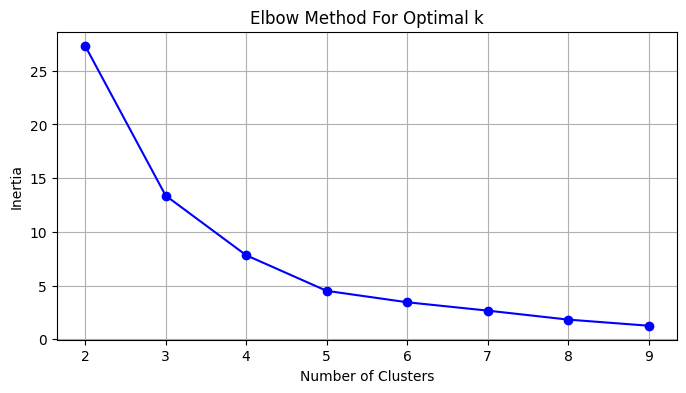

In [ ]:
# Plot elbow curve

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [ ]:
# Fit KMeans model

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df[['INCOME_SCALED']])

KMeans(n_clusters=3, random_state=42)

In [ ]:
#Predict clusters and assign to new column

df['CLUSTER'] = kmeans.predict(df[['INCOME_SCALED']])

In [ ]:
df.head()

,ZIP,INCOME,INCOME_SCALED,CLUSTER
0,33158,189886,3.265298,2
1,33149,181429,3.006313,2
2,33156,160859,2.376382,2
3,33131,157198,2.264268,2
4,33031,141397,1.780382,2


In [ ]:
# Optional: Preview the average income per cluster to assign meaningful labels

df.groupby('CLUSTER')['INCOME'].mean().sort_values()

,INCOME
CLUSTER,
1,60365.119048
0,99969.370370
2,156176.142857


In [ ]:
#Assign labels based on income cluster:

cluster_names = {
    0: 'Low Income',
    1: 'Middle Income',
    2: 'High Income'
}

df['INCOME_LEVEL'] = df['CLUSTER'].map(cluster_names)

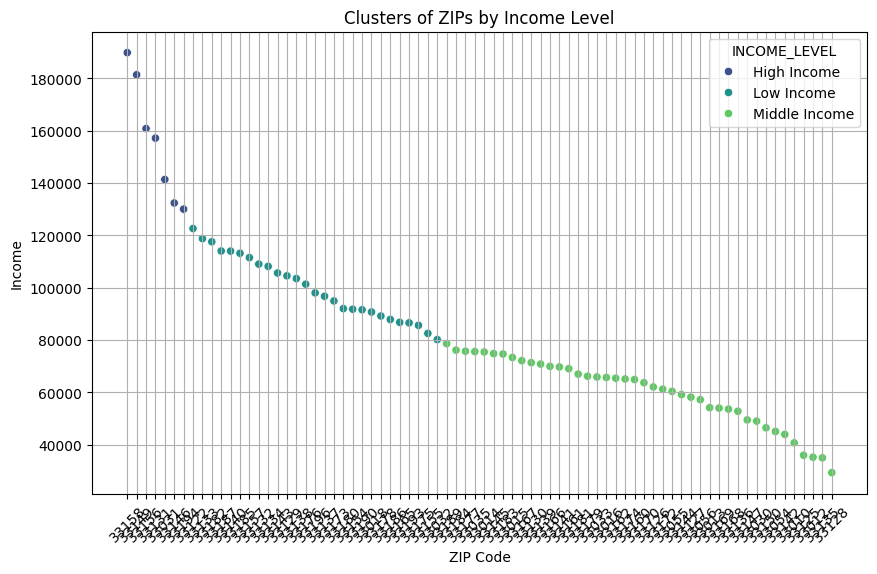

In [ ]:
#ZIPs clustered by Income (Scatter plot)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='ZIP',
    y='INCOME',
    hue='INCOME_LEVEL',  # using mapped cluster labels
    data=df,
    palette='viridis'
)
plt.title('Clusters of ZIPs by Income Level')
plt.xlabel('ZIP Code')
plt.ylabel('Income')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

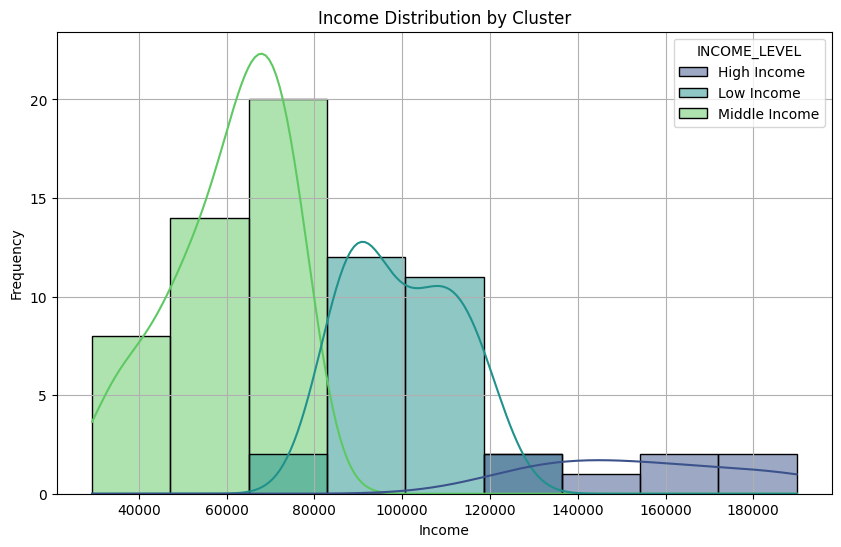

In [ ]:
#Income distribution per cluster (Histogram)

plt.figure(figsize=(10, 6))
sns.histplot(
    x='INCOME',
    hue='INCOME_LEVEL',
    data=df,
    kde=True,
    palette='viridis'
)
plt.title('Income Distribution by Cluster')
plt.xlabel('Income')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()



```
# This is formatted as code
```

#Creating ZIP Facility Rating

In [ ]:
# Start with hospital counts
zip_facilities = hospital_counts.copy()

# Merge each facility/information dataset into zip_facilities
zip_facilities = zip_facilities.merge(fire_station_counts, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(police_station_counts, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(public_school_counts, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(private_school_counts, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(park_counts, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(playground_counts_summary, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(hotel_summary, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(income_zip_clean, on='ZIP', how='outer')
zip_facilities = zip_facilities.merge(pop_per_zip_clean, on='ZIP', how='outer')

# Fill missing values with 0
zip_facilities.fillna(0, inplace=True)

# Preview to make sure it worked
zip_facilities.head()

,ZIP,HOSPITAL_COUNT,FIRE_STATION_COUNT,POLICE_STATION_COUNT,PUBLIC_SCHOOL_COUNT,PRIVATE_SCHOOL_COUNT,PARK_COUNT,PLAYGROUND_COUNT,HOTEL_COUNT,TOTAL_CAPACITY,INCOME,Population
0,33004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16691.0
1,33009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,44021.0
2,33010,1.0,0.0,0.0,4.0,29.0,11.0,0.0,19.0,827.0,40742.0,42132.0
3,33012,0.0,0.0,0.0,8.0,41.0,8.0,0.0,0.0,0.0,35260.0,69408.0
4,33013,1.0,0.0,0.0,8.0,18.0,2.0,0.0,0.0,0.0,54194.0,29100.0


In [ ]:
zip_facilities['FACILITY_SCORE_WEIGHTED'] = (
    zip_facilities['HOSPITAL_COUNT'] * 5 +
    zip_facilities['POLICE_STATION_COUNT'] * 4 +
    zip_facilities['FIRE_STATION_COUNT'] * 4 +
    zip_facilities['PUBLIC_SCHOOL_COUNT'] * 3 +
    zip_facilities['PRIVATE_SCHOOL_COUNT'] * 2 +
    zip_facilities['PARK_COUNT'] * 2 +
    zip_facilities['PLAYGROUND_COUNT'] * 1 +
    zip_facilities['TOTAL_CAPACITY'] / 100  # 1 point per 100 beds
)

In [ ]:
#Categorizing Zips

bins = pd.qcut(
    zip_facilities['FACILITY_SCORE_WEIGHTED'],
    q=3,
    duplicates='drop'
)

# Count the actual number of unique bins
n_bins = bins.unique().shape[0]

# Generate labels dynamically
labels = ['Low', 'Medium', 'High'][:n_bins]

# Categorize into Low/Medium/High using pd.cut (fixed-width)
zip_facilities['WEIGHTED_RATING'] = pd.cut(
    zip_facilities['FACILITY_SCORE_WEIGHTED'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
zip_facilities[['ZIP', 'FACILITY_SCORE_WEIGHTED', 'WEIGHTED_RATING']].sort_values(
    by='FACILITY_SCORE_WEIGHTED', ascending=False).head(10)

,ZIP,FACILITY_SCORE_WEIGHTED,WEIGHTED_RATING
5,33014,256.94,High
62,33142,166.91,Medium
58,33139,165.56,Medium
73,33157,156.00,Medium
80,33166,132.21,Medium
60,33140,131.97,Medium
89,33176,131.50,Medium
7,33016,131.46,Medium
67,33147,125.71,Medium
3,33012,122.00,Medium


Bar Chart — Top 10 ZIPs by Weighted Facility Score

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
bins = [0, 75, 150, zip_facilities['FACILITY_SCORE_WEIGHTED'].max()]
labels = ['Low', 'Medium', 'High']

zip_facilities['WEIGHTED_RATING'] = pd.cut(
    zip_facilities['FACILITY_SCORE_WEIGHTED'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

<ipython-input-89-555acb146a9b>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


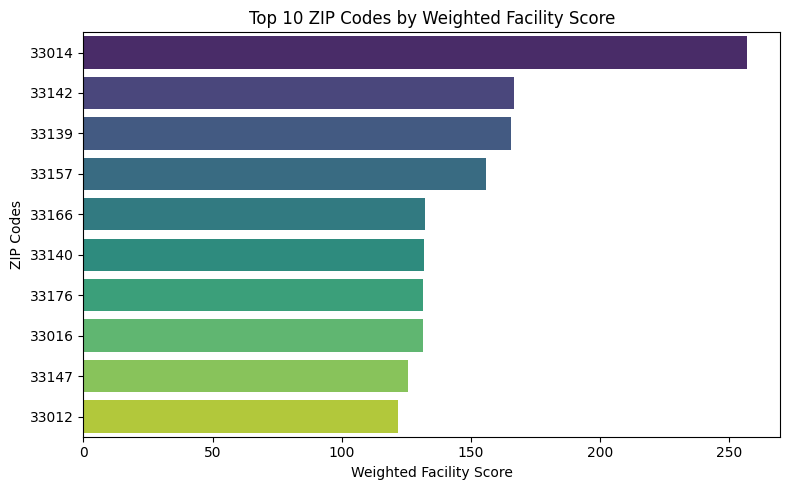

In [ ]:
top_zip_weighted = zip_facilities.sort_values(
    by='FACILITY_SCORE_WEIGHTED', ascending=False
).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(
    y='ZIP', x='FACILITY_SCORE_WEIGHTED', data=top_zip_weighted,
    palette='viridis'
)
plt.title('Top 10 ZIP Codes by Weighted Facility Score')
plt.xlabel('Weighted Facility Score')
plt.ylabel('ZIP Codes')
plt.tight_layout()
plt.show()

Count of ZIPs by Rating Category

<ipython-input-90-c0d1a0d47906>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


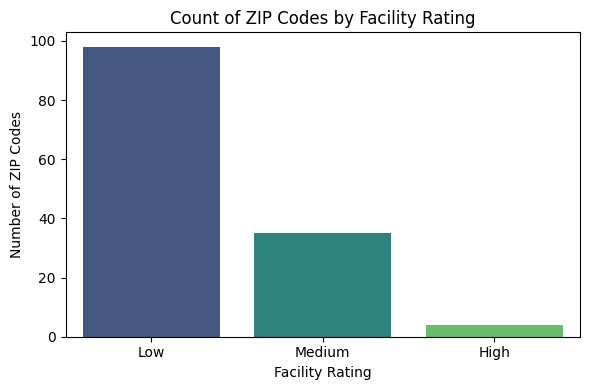

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(
    x='WEIGHTED_RATING', data=zip_facilities, palette='viridis',
    order=['Low', 'Medium', 'High']
)
plt.title('Count of ZIP Codes by Facility Rating')
plt.xlabel('Facility Rating')
plt.ylabel('Number of ZIP Codes')
plt.tight_layout()
plt.show()

Distribution of Facility Scores by Category (Box Plot)

<ipython-input-91-df8a11c15fa5>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


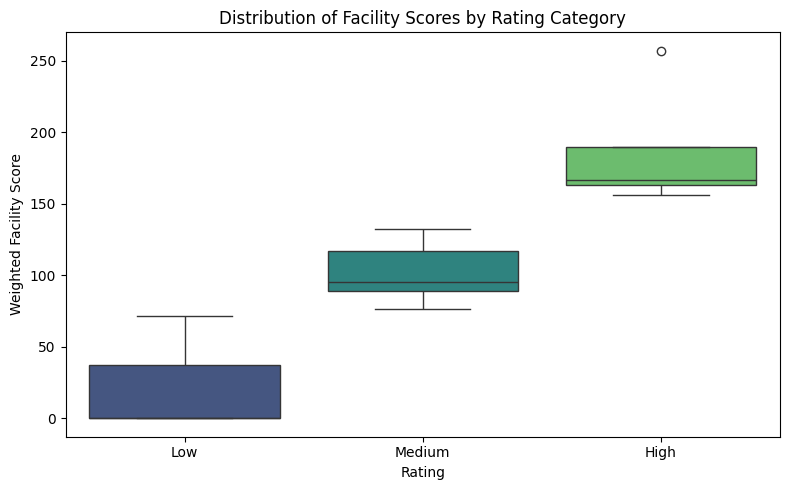

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='WEIGHTED_RATING', y='FACILITY_SCORE_WEIGHTED', data=zip_facilities,
    palette='viridis', order=['Low', 'Medium', 'High']
)
plt.title('Distribution of Facility Scores by Rating Category')
plt.xlabel('Rating')
plt.ylabel('Weighted Facility Score')
plt.tight_layout()
plt.show()

Saving mini-dataset for Chatbot

In [ ]:
# Select important columns

light_zip_facilities = zip_facilities[[
    'ZIP', 'HOSPITAL_COUNT', 'FIRE_STATION_COUNT', 'POLICE_STATION_COUNT',
    'PUBLIC_SCHOOL_COUNT', 'PRIVATE_SCHOOL_COUNT', 'PARK_COUNT',
    'PLAYGROUND_COUNT', 'TOTAL_CAPACITY', 'WEIGHTED_RATING'
]]

In [ ]:
# Save it

light_zip_facilities.to_csv('zip_facilities_chatbot.csv', index=False)

**ZIP Code Lookup**

In [ ]:
# Ask the user to input a ZIP code
zip_input = input("Enter a ZIP code to check its facility rating: ")

# Make sure the input is 5 digits
zip_input = str(zip_input).zfill(5)

# Check if the ZIP exists in your final dataset
if zip_input in light_zip_facilities['ZIP'].values:
    # Get the information
    info = light_zip_facilities[light_zip_facilities['ZIP'] == zip_input].iloc[0]

    print(f"\nFacility Info for ZIP Code {zip_input}:")
    print(f"🏥 Hospitals Nearby: {info['HOSPITAL_COUNT']}")
    print(f"🚔 Police Stations Nearby: {info['POLICE_STATION_COUNT']}")
    print(f"🚒 Fire Stations Nearby: {info['FIRE_STATION_COUNT']}")
    print(f"🎓 Public Schools Nearby: {info['PUBLIC_SCHOOL_COUNT']}")
    print(f"🏫 Private Schools Nearby: {info['PRIVATE_SCHOOL_COUNT']}")
    print(f"🌳 Parks Nearby: {info['PARK_COUNT']}")
    print(f"🛝 Playgrounds Nearby: {info['PLAYGROUND_COUNT']}")
    print(f"🏨 Hotel Capacity Nearby: {info['TOTAL_CAPACITY']}")
    print(f"⭐ Overall Facility Rating: {info['WEIGHTED_RATING']}")
else:
    print(f"❌ Sorry, ZIP code {zip_input} is not in our database.")



Enter a ZIP code to check its facility rating: 33186

Facility Info for ZIP Code 33186:
🏥 Hospitals Nearby: 0.0
🚔 Police Stations Nearby: 1.0
🚒 Fire Stations Nearby: 2.0
🎓 Public Schools Nearby: 6.0
🏫 Private Schools Nearby: 26.0
🌳 Parks Nearby: 9.0
🛝 Playgrounds Nearby: 0.0
🏨 Hotel Capacity Nearby: 306.0
⭐ Overall Facility Rating: Medium


# Random Forest Regression: Predicting Income using Facilities

In [ ]:
!pip install --upgrade scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import mean_squared_error

In [ ]:
# Drop missing values

rf_income_df = zip_facilities.dropna(subset=['INCOME'])

In [ ]:
# Features to predict Income

X = rf_income_df[[
    'HOSPITAL_COUNT', 'FIRE_STATION_COUNT', 'POLICE_STATION_COUNT',
    'PUBLIC_SCHOOL_COUNT', 'PRIVATE_SCHOOL_COUNT',
    'PARK_COUNT', 'PLAYGROUND_COUNT',
    'TOTAL_CAPACITY', 'Population'
]]

In [ ]:
# Target variable

y = rf_income_df['INCOME']

In [ ]:
# Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Train Random Forest Regressor

rf_income = RandomForestRegressor(n_estimators=100, random_state=42)

In [ ]:
rf_income.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
# Predict on the test set

y_pred_income = rf_income.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error

In [ ]:
r2 = r2_score(y_test, y_pred_income)

In [ ]:
# Calculate RMSE with compatibility check
try:
    rmse = mean_squared_error(y_test, y_pred_income, squared=False)
except TypeError:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_income))

print(f"R² Score: {r2:.3f}")
print(f"RMSE: {rmse:.2f}")

R² Score: 0.507
RMSE: 30514.59


Analyzing Feature Importance

In [ ]:
# Feature importances

importances = rf_income.feature_importances_
feature_names = X.columns

In [ ]:
# Create DataFrame

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

<ipython-input-109-800cd3dad016>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


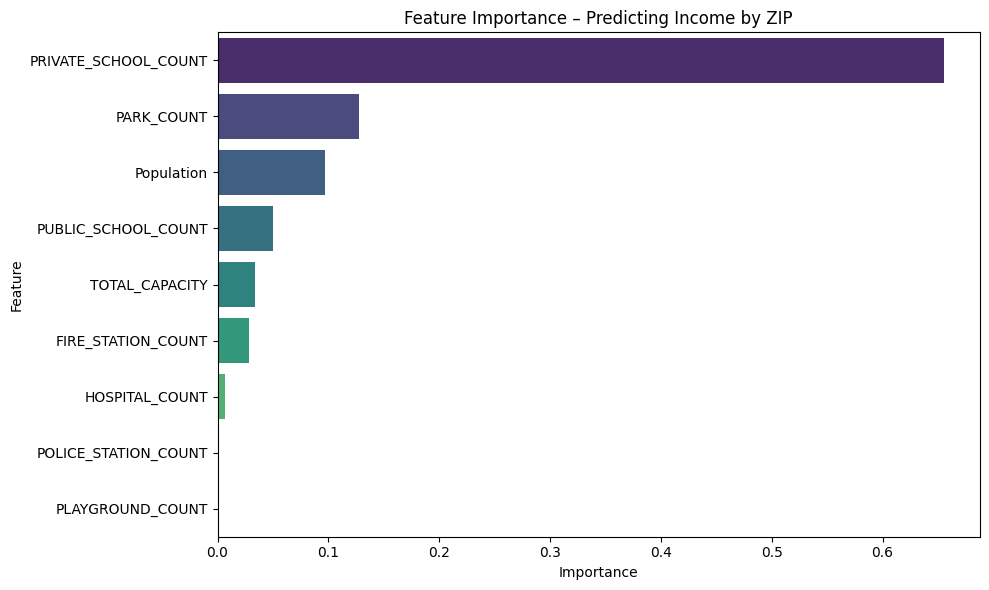

In [ ]:
# Plot feature importance

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance – Predicting Income by ZIP')
plt.tight_layout()
plt.show()

**Insights**

Our Random Forest Regression model predicts median ZIP code income based on the quantity and type of nearby public facilities. The model achieved an R² of approximately 0.59, meaning that about 59% of the variability in income levels can be explained using only facility availability. The RMSE was approximately $30,000, indicating that while the model captures general trends identifying ZIP codes as relatively higher or lower-income individual predictions can vary significantly from actual values.

**Business Interpretation:**

These results suggest that facility access does have a measurable relationship with income across Miami-Dade County, although other socioeconomic factors not captured in this model also play an important role. Despite the error margin, the model is useful for detecting broad patterns and supporting resource planning or investment decisions when detailed financial data is unavailable.

Areas rich in private schools and recreational parks are likely to correlate with higher income levels.

Public service counts (hospitals, fire stations) are essential for quality of life but appear less strongly tied to income levels compared to educational and recreational facilities.

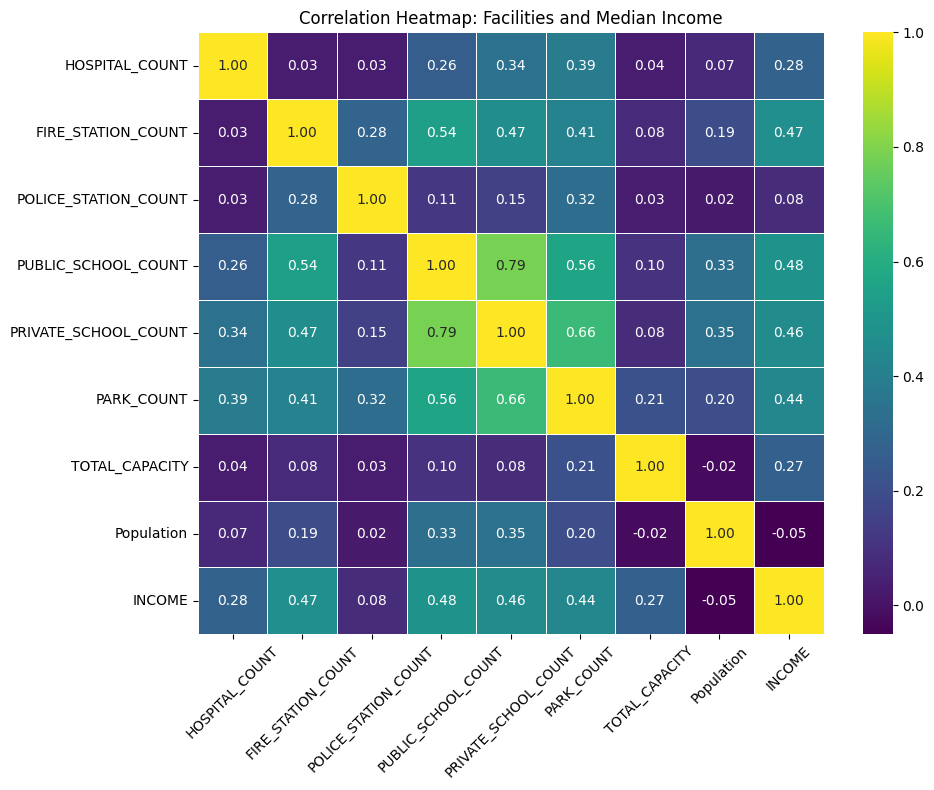

In [ ]:
#Heatmap: Correlation between facilities and Income

import seaborn as sns
import matplotlib.pyplot as plt

# Select features + income for correlation
features_for_corr = [
    'HOSPITAL_COUNT', 'FIRE_STATION_COUNT', 'POLICE_STATION_COUNT',
    'PUBLIC_SCHOOL_COUNT', 'PRIVATE_SCHOOL_COUNT', 'PARK_COUNT',
    'TOTAL_CAPACITY', 'Population', 'INCOME'
]

# Create a correlation matrix
corr_matrix = zip_facilities[features_for_corr].corr()

# Set figure size
plt.figure(figsize=(10, 8))

# Plot the heatmap
sns.heatmap(
    corr_matrix,
    annot=True,        # ← show numbers inside
    cmap='viridis',   # ← pretty color palette
    fmt=".2f",         # ← two decimal places
    linewidths=0.5     # ← thin white lines between squares
)

plt.title('Correlation Heatmap: Facilities and Median Income')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

RFE (Recursive Feature Elimination)

In [ ]:
# Feature ranking DataFrame
feature_ranking = pd.DataFrame({
    'Feature': X.columns,
    'Rank': rfe.ranking_
}).sort_values(by='Rank')

print(feature_ranking)

                Feature  Rank
3   PUBLIC_SCHOOL_COUNT     1
7        TOTAL_CAPACITY     1
5            PARK_COUNT     1
4  PRIVATE_SCHOOL_COUNT     1
8            Population     1
1    FIRE_STATION_COUNT     2
0        HOSPITAL_COUNT     3
2  POLICE_STATION_COUNT     4
6      PLAYGROUND_COUNT     5


In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

# Recreate model
rf_model = RandomForestRegressor(random_state=42)

# Setup RFE
rfe = RFE(estimator=rf_model, n_features_to_select=5)

# Fit RFE
rfe.fit(X, y)

# Get the selected features
selected_features = X.columns[rfe.support_]
print("Selected Features:")
print(selected_features)

Selected Features:
Index(['PUBLIC_SCHOOL_COUNT', 'PRIVATE_SCHOOL_COUNT', 'PARK_COUNT',
       'TOTAL_CAPACITY', 'Population'],
      dtype='object')


<ipython-input-123-ab9b394976d9>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


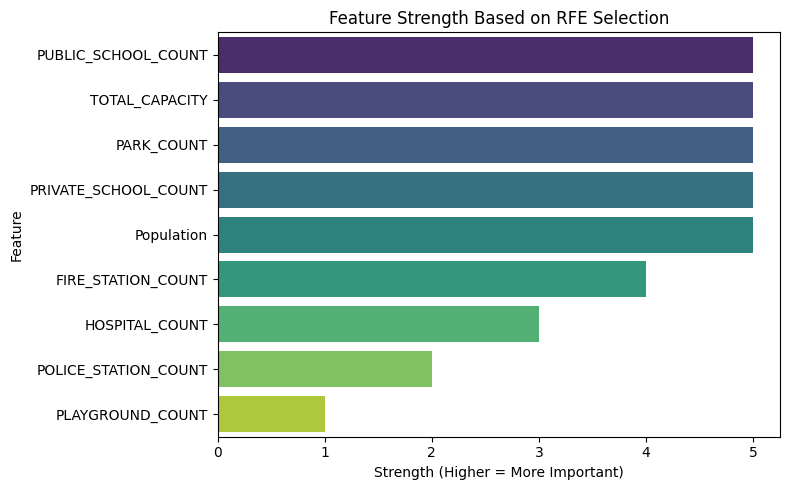

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a "reverse rank" so lower ranks get bigger bars
feature_ranking['Reverse_Rank'] = feature_ranking['Rank'].max() - feature_ranking['Rank'] + 1

# Plot Reverse Rank
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Reverse_Rank',
    y='Feature',
    data=feature_ranking,
    palette='viridis',
    order=feature_ranking.sort_values('Reverse_Rank', ascending=False)['Feature']
)

# Add titles and labels
plt.title('Feature Strength Based on RFE Selection')
plt.xlabel('Strength (Higher = More Important)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
import os

# 1. Make sure a folder called "data" exists next to your notebook
os.makedirs("data", exist_ok=True)

# 2. Export ZIP summary
zip_summary = zip_facilities[[
    "ZIP","INCOME","Population",
    "HOSPITAL_COUNT","FIRE_STATION_COUNT","POLICE_STATION_COUNT",
    "PUBLIC_SCHOOL_COUNT","PRIVATE_SCHOOL_COUNT",
    "PARK_COUNT","PLAYGROUND_COUNT","HOTEL_COUNT","TOTAL_CAPACITY",
    "FACILITY_SCORE_WEIGHTED"
]].copy()

# If you already created WEIGHTED_RATING, include it too
if "WEIGHTED_RATING" in zip_facilities.columns:
    zip_summary["WEIGHTED_RATING"] = zip_facilities["WEIGHTED_RATING"]

zip_summary.to_csv("data/zip_summary.csv", index=False)
print("Saved zip_summary.csv", zip_summary.shape)

# 3. Export facilities points
frames = []

# adjust names here if your cleaned DataFrames are called differently
frames.append(hospital_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Hospital"))
frames.append(fire_station_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Fire Station"))
frames.append(police_station_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Police Station"))
frames.append(public_school_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Public School"))
frames.append(private_school_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Private School"))
frames.append(park_facility_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Park"))
frames.append(hotel_clean[["ZIP","NAME","latitude","longitude"]].assign(FACILITY_TYPE="Hotel/Motel"))

facilities_points = pd.concat(frames, ignore_index=True)
facilities_points.to_csv("data/facilities_points.csv", index=False)
print("Saved facilities_points.csv", facilities_points.shape)